# Retail Demand Forecasting
## Data Cleaning and Initial EDA

This notebook focuses on understanding and preparing the retail sales data
and performing an initial exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "../data/raw/"

train = pd.read_csv(DATA_PATH + "train.csv")
test = pd.read_csv(DATA_PATH + "test.csv")
stores = pd.read_csv(DATA_PATH + "stores.csv")
transactions = pd.read_csv(DATA_PATH + "transactions.csv")
holidays = pd.read_csv(DATA_PATH + "holidays_events.csv")
oil = pd.read_csv(DATA_PATH + "oil.csv")

In [3]:
datasets = {
    "train": train,
    "test": test,
    "stores": stores,
    "transactions": transactions,
    "holidays": holidays,
    "oil": oil
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

train: (3000888, 6)
test: (28512, 5)
stores: (54, 5)
transactions: (83488, 3)
holidays: (350, 6)
oil: (1218, 2)


In [4]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.head())


TRAIN


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



TEST


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0



STORES


...

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922



HOLIDAYS


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False



OIL


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [5]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.dtypes)


TRAIN


id               int64
date               str
store_nbr        int64
family             str
sales          float64
onpromotion      int64
dtype: object


TEST


id             int64
date             str
store_nbr      int64
family           str
onpromotion    int64
dtype: object


STORES


...

date              str
store_nbr       int64
transactions    int64
dtype: object


HOLIDAYS


date            str
type            str
locale          str
locale_name     str
description     str
transferred    bool
dtype: object


OIL


date              str
dcoilwtico    float64
dtype: object

In [6]:
date_columns = {
    "train": train,
    "test": test,
    "transactions": transactions,
    "holidays": holidays,
    "oil": oil
}

for name, df in date_columns.items():
    df["date"] = pd.to_datetime(df["date"])

In [7]:
train["date"].min(), train["date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [8]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    display(missing)


TRAIN


Series([], dtype: int64)


TEST


Series([], dtype: int64)


STORES


...

Series([], dtype: int64)


HOLIDAYS


Series([], dtype: int64)


OIL


dcoilwtico    43
dtype: int64

In [9]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicates")

train: 0 duplicates
test: 0 duplicates
stores: 0 duplicates
transactions: 0 duplicates
holidays: 0 duplicates
oil: 0 duplicates


In [10]:
print("Rows:", len(train))
print("Stores:", train["store_nbr"].nunique())
print("Product Families:", train["family"].nunique())
print("Start Date:", train["date"].min())
print("End Date:", train["date"].max())

Rows: 3000888
Stores: 54
Product Families: 33
Start Date: 2013-01-01 00:00:00
End Date: 2017-08-15 00:00:00


In [11]:
duplicate_keys = train.duplicated(
    subset=["date", "store_nbr", "family"]
).sum()

print("Duplicate date-store-family combinations:", duplicate_keys)

Duplicate date-store-family combinations: 0


In [12]:
train["sales"].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [13]:
print("Zero sales:", (train["sales"] == 0).sum())
print(
    "Zero sales percentage:",
    round((train["sales"] == 0).mean() * 100, 2),
    "%"
)

Zero sales: 939130
Zero sales percentage: 31.3 %


In [14]:
print("Negative sales:", (train["sales"] < 0).sum())

Negative sales: 0


In [15]:
print(
    "Rows with promotion:",
    round((train["onpromotion"] > 0).mean() * 100, 2),
    "%"
)

Rows with promotion: 20.37 %


In [16]:
oil[oil["dcoilwtico"].isna()]

,date,dcoilwtico
0,2013-01-01,NaN
14,2013-01-21,NaN
34,2013-02-18,NaN
63,2013-03-29,NaN
104,2013-05-27,NaN
132,2013-07-04,NaN
174,2013-09-02,NaN
237,2013-11-28,NaN
256,2013-12-25,NaN
261,2014-01-01,NaN


In [17]:
oil_missing_dates = oil.loc[
    oil["dcoilwtico"].isna(), "date"
]

holidays[holidays["date"].isin(oil_missing_dates)][
    ["date", "type", "locale", "description"]
]

,date,type,locale,description
41,2013-01-01,Holiday,National,Primer dia del ano
89,2013-12-25,Holiday,National,Navidad
92,2014-01-01,Holiday,National,Primer dia del ano
99,2014-04-18,Holiday,National,Viernes Santo
120,2014-07-04,Event,National,Mundial de futbol Brasil: Cuartos de Final
155,2014-12-25,Holiday,National,Navidad
159,2015-01-01,Holiday,National,Primer dia del ano
162,2015-02-16,Holiday,National,Carnaval
166,2015-04-03,Holiday,National,Viernes Santo
179,2015-07-03,Holiday,Local,Cantonizacion de El Carmen


In [18]:
oil["dcoilwtico"] = oil["dcoilwtico"].ffill().bfill()

### Handling Missing Oil Prices

The oil dataset contains missing values in the `dcoilwtico` column, which represents the daily oil price.

During the inspection, we found 43 missing oil-price values. Several of the missing dates also appear in the holidays dataset, but not all missing dates were verified as holidays.

Since oil price is a time-dependent feature, we will not remove these rows. Instead, missing values will be imputed using forward fill, with backward fill used only when no previous value is available.

This approach preserves the dates and avoids removing observations that may be important for demand analysis.

In [19]:
oil["dcoilwtico"].isna().sum()

np.int64(0)

After imputation, we verify that no missing oil-price values remain.

### Duplicate Check

We check for duplicate rows across all datasets to ensure that duplicated observations do not affect the analysis or lead to incorrect aggregations during data integration.

In [20]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

train: 0 duplicate rows
test: 0 duplicate rows
stores: 0 duplicate rows
transactions: 0 duplicate rows
holidays: 0 duplicate rows
oil: 0 duplicate rows


### Train Data Granularity Check

The training data is expected to contain one observation for each combination of date, store, and product family. We therefore check whether any duplicate combinations exist.

In [21]:
train.duplicated(
    subset=["date", "store_nbr", "family"]
).sum()

np.int64(0)

### Date Validation

Since this project focuses on time-series demand forecasting, we verify that the date columns are correctly formatted and inspect the date ranges across the datasets.

In [22]:
for name, df in datasets.items():
    if "date" in df.columns:
        print(f"{name}: {df['date'].dtype}")

train: datetime64[us]
test: datetime64[us]
transactions: datetime64[us]
holidays: datetime64[us]
oil: datetime64[us]


In [23]:
for name, df in datasets.items():
    if "date" in df.columns:
        print(
            f"{name}: "
            f"{df['date'].min().date()} → "
            f"{df['date'].max().date()}"
        )

train: 2013-01-01 → 2017-08-15
test: 2017-08-16 → 2017-08-31
transactions: 2013-01-01 → 2017-08-15
holidays: 2012-03-02 → 2017-12-26
oil: 2013-01-01 → 2017-08-31


In [24]:
print(
    "Train unique dates:",
    train["date"].nunique()
)

print(
    "Train total rows:",
    len(train)
)

Train unique dates: 1684
Train total rows: 3000888


In [25]:
print(
    "Train date range:",
    train["date"].max() - train["date"].min()
)

Train date range: 1687 days 00:00:00


In [26]:
expected_dates = pd.date_range(
    start=train["date"].min(),
    end=train["date"].max(),
    freq="D"
)

actual_dates = train["date"].drop_duplicates().sort_values()

missing_dates = expected_dates.difference(actual_dates)

print("Expected dates:", len(expected_dates))
print("Actual dates:", len(actual_dates))
print("Missing dates:", len(missing_dates))

Expected dates: 1688
Actual dates: 1684
Missing dates: 4


In [27]:
print("Missing dates:")
for date in missing_dates:
    print(date.date())

Missing dates:
2013-12-25
2014-12-25
2015-12-25
2016-12-25


### Missing Calendar Dates

The training data contains four missing calendar dates:

- December 25, 2013
- December 25, 2014
- December 25, 2015
- December 25, 2016

All four missing dates correspond to December 25. These dates are not individual missing sales values; the entire dates are absent from the training dataset.

Therefore, we will not impute or add sales observations for these dates. Adding artificial sales values could introduce assumptions that are not supported by the data.

### Decision

The missing dates will be kept as absent dates during the initial analysis. 
The forecasting models will use the available observations without creating artificial demand values for these dates.

### Sales Validation

Sales is the target variable for the demand forecasting task. We inspect its distribution, range, zero values, and negative values to identify potential data quality issues before performing exploratory analysis.

In [28]:
print("Sales summary:")
display(train["sales"].describe())

Sales summary:


count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [29]:
print("Zero sales:", (train["sales"] == 0).sum())
print("Zero sales percentage:", round((train["sales"] == 0).mean() * 100, 2), "%")
print("Negative sales:", (train["sales"] < 0).sum())

Zero sales: 939130
Zero sales percentage: 31.3 %
Negative sales: 0


### Sales Validation Result

The sales variable contains no negative values, indicating no obvious invalid negative demand records.

However, 31.3% of the observations have zero sales. These zero values are retained because they represent potentially meaningful demand patterns and will be considered during the analysis of regular and intermittent demand.

## Initial Exploratory Data Analysis

The initial EDA examines overall sales trends and patterns over time, followed by differences across product families, stores, months, weekdays, and promotion status.

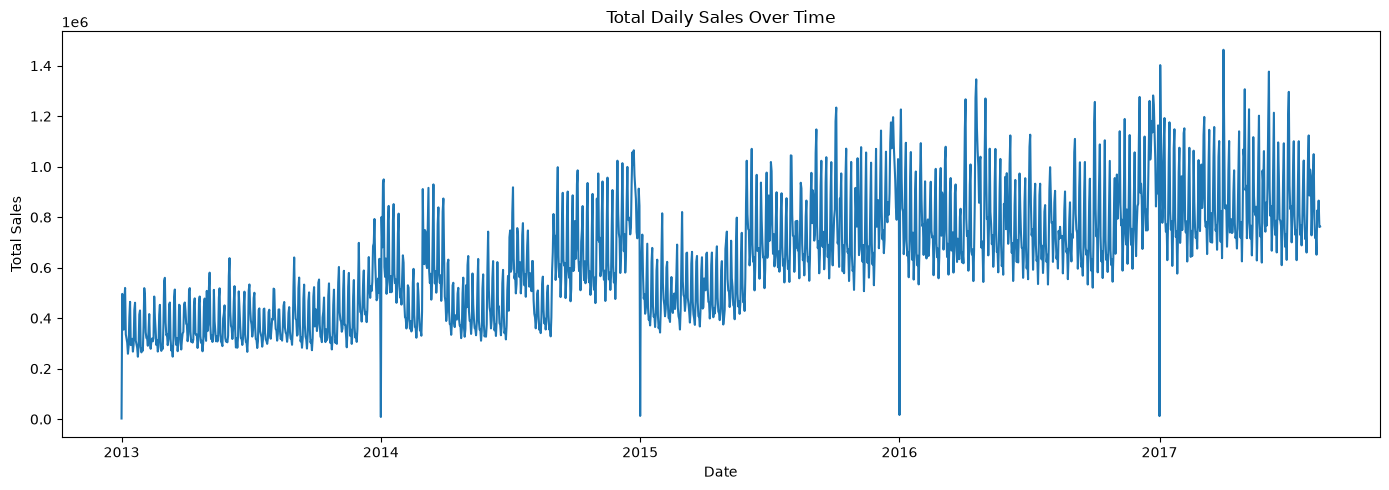

In [30]:
daily_sales = (
    train.groupby("date", as_index=False)["sales"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Insight

The overall daily sales show an increasing trend over the observed period, with sales levels generally higher in later years than in the earlier years.

The series also shows strong day-to-day variability and recurring patterns over time, suggesting the presence of temporal seasonality.

Several dates show very low or zero total sales, which is consistent with the high proportion of zero-sales observations identified during data validation. These observations are retained because they may represent meaningful demand patterns.

### 1. Overall Sales Trend with 7-Day Rolling Average

A 7-day rolling average is used to smooth daily fluctuations and provide a clearer view of the underlying sales trend.

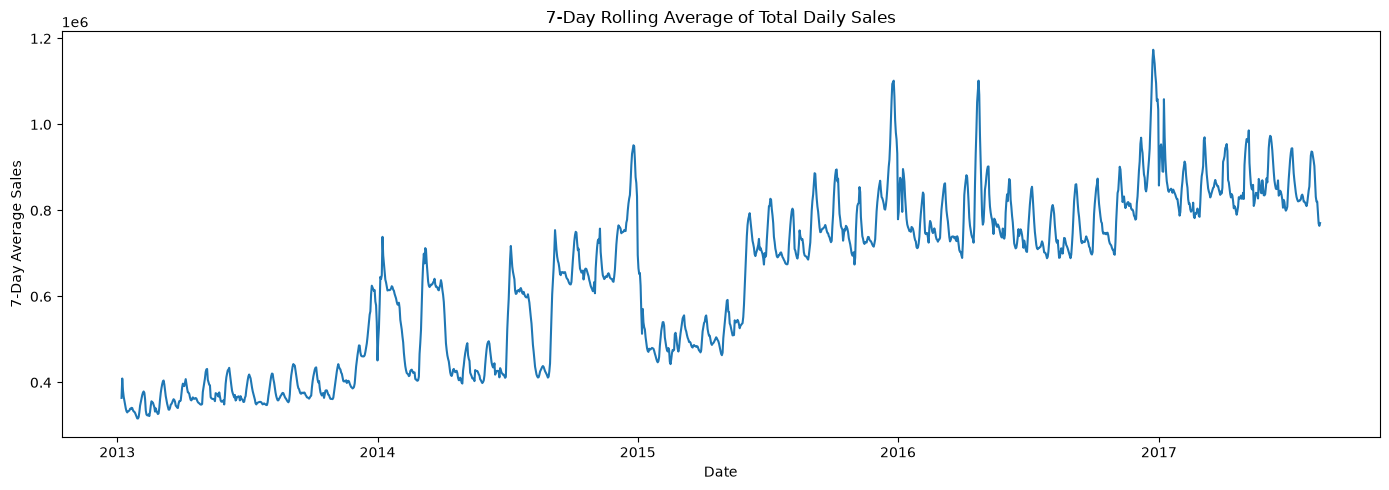

In [31]:
daily_sales["rolling_7d"] = (
    daily_sales["sales"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_7d"]
)

plt.title("7-Day Rolling Average of Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("7-Day Average Sales")

plt.tight_layout()
plt.show()

### Insight

The 7-day rolling average shows an overall upward trend in sales over the observed period.

Sales levels are generally higher in 2016 and 2017 compared with the earlier years. The series also contains recurring fluctuations, suggesting that temporal patterns and seasonality may influence demand.

A noticeable decline occurs during part of 2015, followed by a recovery and a higher sales level in the later period.

### 3. Top 10 Product Families by Total Sales

We aggregate total sales by product family to identify the product categories that contribute most to overall demand.

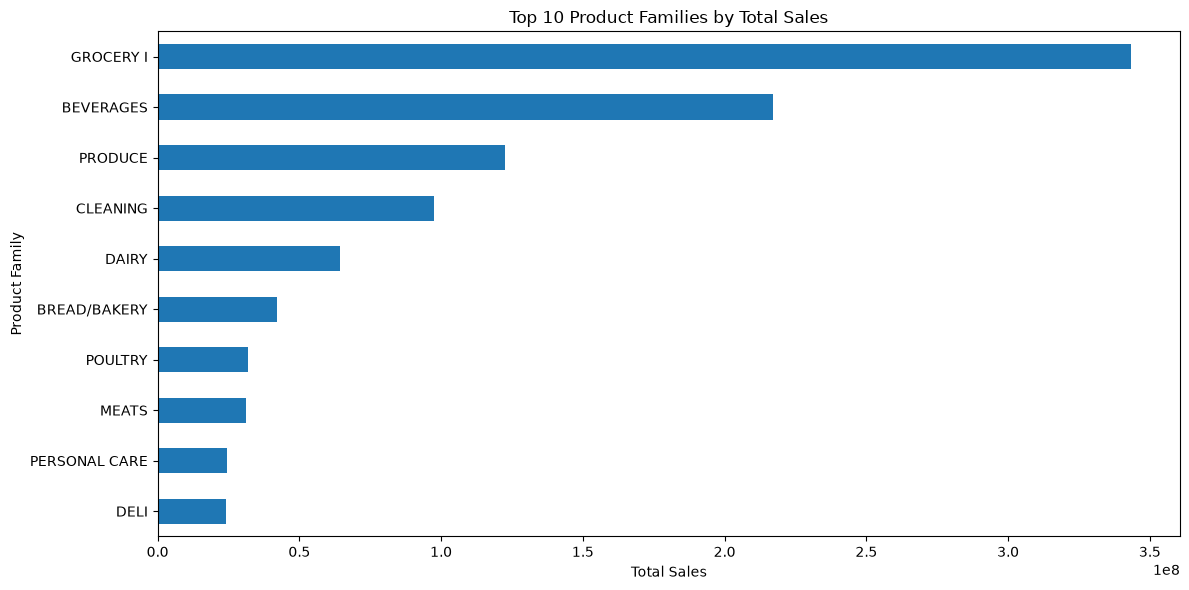

In [32]:
family_sales = (
    train.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
)

top_10_families = family_sales.head(10)

plt.figure(figsize=(12, 6))

top_10_families.sort_values().plot(kind="barh")

plt.title("Top 10 Product Families by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Family")

plt.tight_layout()
plt.show()

### Insight

GROCERY I has the highest total sales among all product families, followed by BEVERAGES and PRODUCE.

The difference between the top product family and the others is substantial, indicating that demand is not evenly distributed across product families.

This suggests that product family should be considered as an important feature when building the demand forecasting model.

### 4. Sales by Promotion Status

We compare total sales on days with and without promotions to examine whether promotional activity is associated with higher demand.

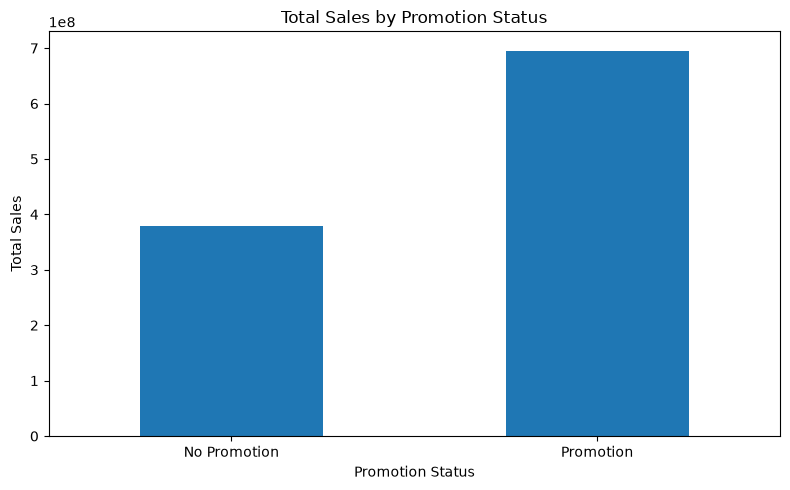

In [33]:
promotion_sales = (
    train.groupby(train["onpromotion"] > 0)["sales"]
    .sum()
)

promotion_sales.index = ["No Promotion", "Promotion"]

plt.figure(figsize=(8, 5))

promotion_sales.plot(kind="bar")

plt.title("Total Sales by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Promotion Sales Validation

Total sales are higher for observations with promotions. However, total sales alone may be affected by the different number of observations in each group.

Therefore, we compare the average sales per observation to better understand the relationship between promotion activity and demand.

In [34]:
promotion_summary = (
    train.groupby(train["onpromotion"] > 0)["sales"]
    .agg(["count", "mean", "median", "sum"])
)

promotion_summary.index = ["No Promotion", "Promotion"]

display(promotion_summary)

,count,mean,median,sum
No Promotion,2389559,158.246681,3.0,3.781398e+08
Promotion,611329,1137.693730,373.0,6.955052e+08


In [35]:
no_promo_mean = promotion_summary.loc["No Promotion", "mean"]
promo_mean = promotion_summary.loc["Promotion", "mean"]

percentage_difference = (
    (promo_mean - no_promo_mean) / no_promo_mean
) * 100

print(
    "Average sales difference:",
    round(percentage_difference, 2),
    "%"
)

Average sales difference: 618.94 %


### Insight

Observations with promotions have substantially higher average sales than observations without promotions.

The average sales are 1,137.69 for promoted observations compared with 158.25 for non-promoted observations, representing a difference of approximately 618.94%.

This strong association suggests that promotion activity may be an important predictive feature for demand forecasting. However, this analysis does not establish a causal relationship between promotions and sales.

### 5. Average Sales by Month

We examine the average sales across months to identify recurring monthly patterns and potential seasonal effects in demand.

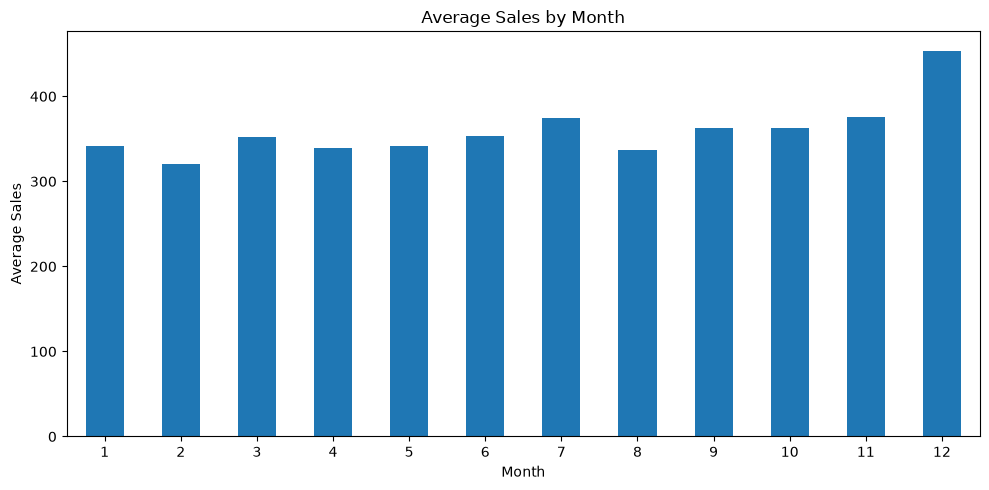

In [36]:
monthly_sales = (
    train.groupby(train["date"].dt.month)["sales"]
    .mean()
)

plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight

Average sales vary across months, indicating a recurring monthly pattern in demand.

December has the highest average sales, while February has the lowest. Although the differences between most months are moderate, the monthly variation suggests that month-related seasonal features may be useful for demand forecasting.

## Advanced EDA & Feature Exploration

The following sections extend the initial exploratory analysis with calendar-based patterns, store-level differences, and feature preparation for demand forecasting.

### 6. Sales by Day of Week

We examine average sales across days of the week to identify whether demand follows a recurring weekly pattern.

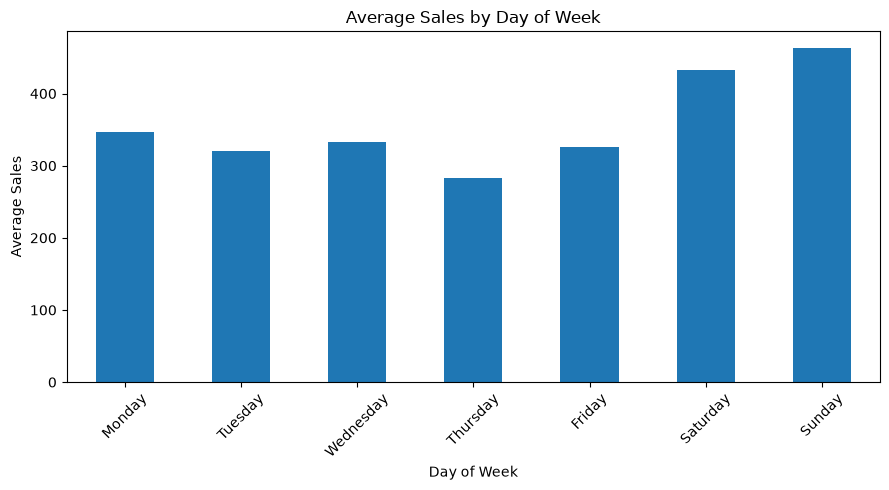

weekday
Monday       346.54
Tuesday      319.82
Wednesday    332.91
Thursday     283.54
Friday       325.24
Saturday     433.34
Sunday       463.09
Name: sales, dtype: float64


In [37]:
train['weekday'] = train['date'].dt.day_name()

weekday_sales = train.groupby('weekday')['sales'].mean()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
                  'Friday', 'Saturday', 'Sunday']
weekday_sales = weekday_sales.reindex(weekday_order)

plt.figure(figsize=(9, 5))
weekday_sales.plot(kind='bar')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(weekday_sales.round(2))

### Insight

Sales are highest on weekends, with Sunday (463.09) and Saturday (433.34) showing the strongest average demand. Thursday records the lowest average sales (283.54), while the remaining weekdays (Monday through Friday) show relatively similar levels, ranging from 283.54 to 346.54.

This weekly pattern, with weekend sales roughly 1.6 times higher than the weakest weekday, suggests that day-of-week should be included as a categorical feature in the forecasting model to capture this recurring demand cycle.

### 7. Sales by Year (Seasonality)

We examine sales trends across years to identify year-over-year growth.

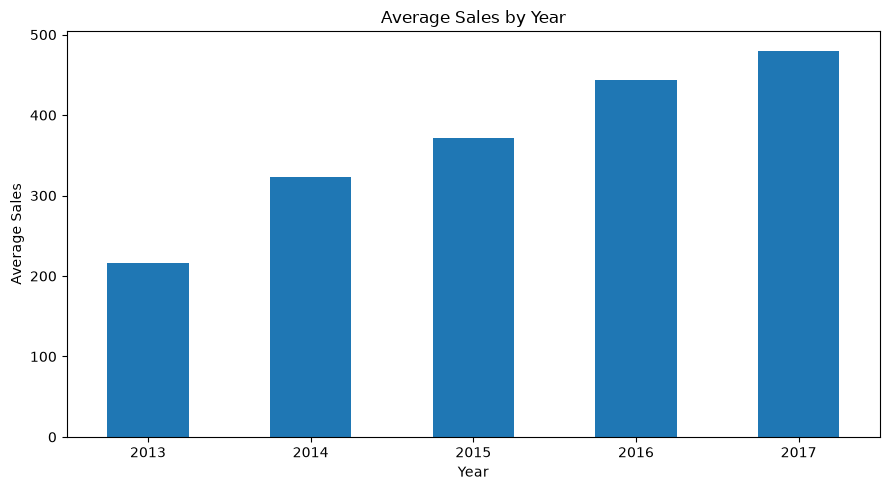

year
2013    216.48
2014    322.94
2015    371.36
2016    443.79
2017    480.12
Name: sales, dtype: float64


In [38]:
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month

yearly_sales = train.groupby('year')['sales'].mean()

plt.figure(figsize=(9, 5))
yearly_sales.plot(kind='bar')
plt.title('Average Sales by Year')
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(yearly_sales.round(2))

### Verifying the Growth Trend

To verify whether the year-over-year growth reflects genuine demand increase or incomplete data tracking, we examine the PRODUCE family in isolation, since fresh categories are more likely to have been added to the system gradually.

In [39]:
produce_by_year = train[train['family'] == 'PRODUCE'].groupby('year')['sales'].mean()
print(produce_by_year.round(2))

year
2013       3.70
2014    1196.20
2015    1302.19
2016    2244.96
2017    2388.27
Name: sales, dtype: float64


### Insight

Average sales show a clear upward trend from 2013 (216.48) to 2017 (480.12). However, this growth is partly an artifact of incomplete tracking in early years: the PRODUCE family, for example, shows average sales of only 3.70 in 2013 compared with 1,196.20 in 2014 — a 323-fold increase that reflects the category not being fully recorded early in the dataset, rather than genuine demand growth.

This confirms that year should be included as a feature with caution, and that per-family tracking start dates should be verified (similar to the store cold-start check) before treating year-over-year growth as a reliable trend signal.

### 8. Sales by Store

We examine sales distribution across individual stores to identify high- and low-performing locations.

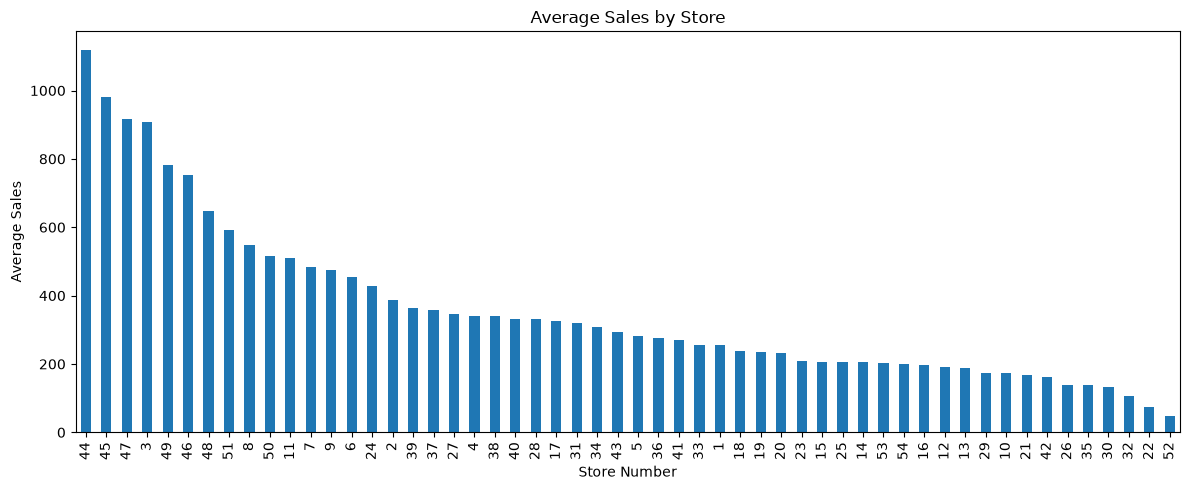

store_nbr
44    1117.245254
45     980.673908
47     916.798209
3      908.405495
49     781.330450
Name: sales, dtype: float64
...
store_nbr
35    138.139340
30    132.838006
32    107.100626
22     73.601845
52     48.516694
Name: sales, dtype: float64


In [40]:
store_sales = train.groupby('store_nbr')['sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
store_sales.plot(kind='bar')
plt.title('Average Sales by Store')
plt.xlabel('Store Number')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

print(store_sales.head(5))
print("...")
print(store_sales.tail(5))

### Verifying Store Coverage

Before interpreting store-level averages, we verify whether all stores have equal data coverage across the period.

In [41]:
store_days = train.groupby('store_nbr')['date'].nunique()

print("Days recorded per store — Store 52:", store_days.loc[52])
print("Average days across all stores:", store_days.mean().round(0))

Days recorded per store — Store 52: 1684
Average days across all stores: 1684.0


### Insight

Average sales vary substantially across stores, from 1,117.25 (Store 44) to 48.52 (Store 52) — roughly a 23-fold difference. All stores have identical data coverage (1,684 recorded days), so the gap is not caused by missing records.

However, Store 52 opened partway through the data period, meaning its average includes an extended stretch of zero sales prior to opening rather than reflecting weak performance once operational. Store-level averages should therefore be interpreted alongside each store's operational start date, and a store-opening feature (or excluding pre-opening records) would improve the reliability of store comparisons.

### 9. Sales by Store Type

We examine whether store type, as defined in the stores metadata, is associated with different demand levels.

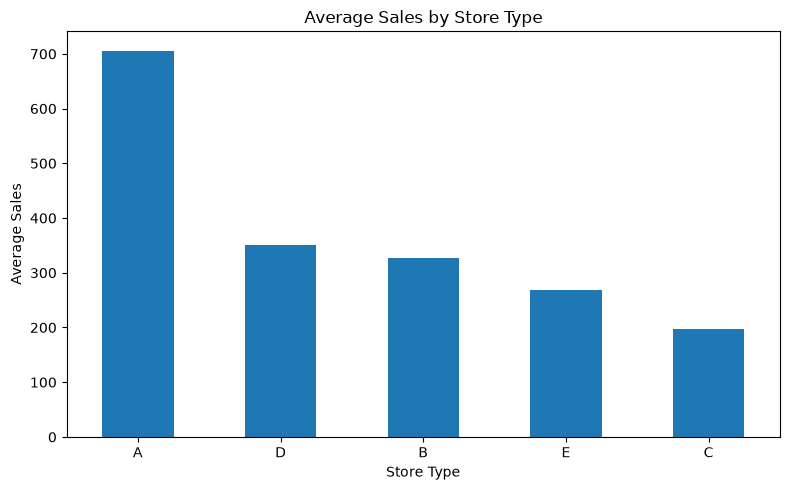

type
A    705.88
D    350.98
B    326.74
E    269.12
C    197.26
Name: sales, dtype: float64


In [42]:
stores = pd.read_csv(DATA_PATH + "stores.csv")
train_stores = train.merge(stores, on='store_nbr', how='left')

type_sales = train_stores.groupby('type')['sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
type_sales.plot(kind='bar')
plt.title('Average Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(type_sales.round(2))

### Insight

Store type is strongly associated with sales volume. Type A stores average 705.88 in sales, more than double the next highest type (D at 350.98), while Type C records the lowest average at 197.26 — a 3.6-fold gap between the highest and lowest types.

Notably, the ordering does not follow the alphabetical labels (D outperforms B, and E outperforms C), indicating that store type reflects an operational classification rather than a simple size ranking. This makes store type a useful categorical feature for the forecasting model, as it captures systematic differences in demand levels that are not evident from the store number alone.

### 10. Promotion Effect by Product Family

The initial analysis showed that promoted observations have substantially higher average sales overall. We now examine whether this effect is consistent across product families or concentrated in specific categories.

In [43]:
promo_effect = train.groupby(['family', train['onpromotion'] > 0])['sales'].mean().unstack()
promo_effect.columns = ['No Promotion', 'Promotion']

promo_effect['lift_pct'] = (
    (promo_effect['Promotion'] - promo_effect['No Promotion']) 
    / promo_effect['No Promotion'] * 100
).round(1)

promo_effect = promo_effect.sort_values('lift_pct', ascending=False)

print(promo_effect.head(10))
print("...")
print(promo_effect.tail(10))

                            No Promotion    Promotion  lift_pct
family                                                         
SCHOOL AND OFFICE SUPPLIES      1.022018    44.529107    4257.0
BABY CARE                       0.109624     1.660377    1414.6
PET SUPPLIES                    3.507379    15.835244     351.5
HOME AND KITCHEN II            10.275239    41.158133     300.6
PRODUCE                       792.101911  2438.220197     207.8
HOME APPLIANCES                 0.456876     1.396552     205.7
LAWN AND GARDEN                 5.510703    16.786862     204.6
HOME CARE                     101.956009   309.444864     203.5
PLAYERS AND ELECTRONICS         6.081521    17.363958     185.5
BEAUTY                          3.078452     8.291266     169.3
...
                No Promotion    Promotion  lift_pct
family                                             
MEATS             303.081088   467.301631      54.2
PERSONAL CARE     220.878968   338.746698      53.4
BREAD/BAKERY      37

### Insight

The promotional effect varies dramatically across product families, ranging from a 4,257% lift (School and Office Supplies) to 23.9% (Prepared Foods) — a spread that the aggregate figure of 618.94% conceals entirely.

However, the largest percentage lifts occur in categories with very low baseline sales: School and Office Supplies averages 1.02 units without promotion versus 44.53 with, and Baby Care averages 0.11 versus 1.66. In absolute terms, the most commercially significant lift is in Produce, which rises from 792.10 to 2,438.22 — a 207.8% increase on an already substantial base.

Books shows no promotional data at all, indicating the category was never promoted across the entire period.

This suggests that promotion should be modelled as an interaction with product family rather than as a single global effect, since the response magnitude differs by two orders of magnitude between categories.

### 11. Holiday Effect on Sales

We examine whether sales differ on public holidays compared with regular days. The holidays dataset distinguishes several event types, including transferred holidays that are officially moved to another date.

In [44]:
holidays = pd.read_csv(DATA_PATH + "holidays_events.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

national_holidays = holidays[
    (holidays["locale"] == "National") & (holidays["transferred"] == False)
]["date"].unique()

daily_sales = train.groupby("date")["sales"].mean()

holiday_sales = daily_sales[daily_sales.index.isin(national_holidays)]
regular_sales = daily_sales[~daily_sales.index.isin(national_holidays)]

print("Holidays:", len(holiday_sales), "days | Mean sales:", round(holiday_sales.mean(), 2))
print("Regular:", len(regular_sales), "days | Mean sales:", round(regular_sales.mean(), 2))
print("Difference:", round((holiday_sales.mean() - regular_sales.mean()) / regular_sales.mean() * 100, 2), "%")

Holidays: 136 days | Mean sales: 419.34
Regular: 1548 days | Mean sales: 352.37
Difference: 19.01 %


In [45]:
np.random.seed(42)

random_diffs = []
for _ in range(10):
    random_days = np.random.choice(regular_sales.index, size=136, replace=False)
    random_mean = daily_sales[daily_sales.index.isin(random_days)].mean()
    others_mean = daily_sales[~daily_sales.index.isin(random_days)].mean()
    random_diffs.append((random_mean - others_mean) / others_mean * 100)

print("Holiday effect:", round((holiday_sales.mean() - regular_sales.mean()) / regular_sales.mean() * 100, 2), "%")
print("Random samples (10 runs):", [round(d, 2) for d in random_diffs])
print("Max random difference:", round(max(abs(d) for d in random_diffs), 2), "%")

Holiday effect: 19.01 %
Random samples (10 runs): [np.float64(-2.04), np.float64(-6.02), np.float64(2.15), np.float64(-2.54), np.float64(-0.87), np.float64(2.23), np.float64(-4.02), np.float64(3.44), np.float64(1.65), np.float64(-5.41)]
Max random difference: 6.02 %


### Insight

Sales on national holidays average 419.34 compared with 352.37 on regular days, a 19.01% increase across 136 holiday observations.

To confirm this is not an artifact of random variation, we compared the holiday effect against ten random samples of equal size (136 days) drawn from regular days. The random differences ranged from -6.02% to +3.44%, with a maximum absolute deviation of 6.02% — roughly one third of the observed holiday effect, and centred around zero as expected for noise.

This confirms that national holidays represent a genuine demand signal rather than random fluctuation, and should be included as a binary feature in the forecasting model. Transferred holidays were excluded from this analysis, as the dataset documentation indicates they behave as ordinary working days.

### 12. Merging Supplementary Data

We merge store metadata, daily transactions, and oil prices into the main dataset to prepare a unified table for feature exploration and modelling.

In [46]:
transactions = pd.read_csv(DATA_PATH + "transactions.csv")
transactions["date"] = pd.to_datetime(transactions["date"])

oil = pd.read_csv(DATA_PATH + "oil.csv")
oil["date"] = pd.to_datetime(oil["date"])
oil["dcoilwtico"] = oil["dcoilwtico"].ffill().bfill()

df = train.merge(stores, on="store_nbr", how="left")
df = df.merge(transactions, on=["date", "store_nbr"], how="left")
df = df.merge(oil, on="date", how="left")

df["dcoilwtico"] = df["dcoilwtico"].ffill().bfill()

print("Shape after merging:", df.shape)
print("\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])

Shape after merging: (3000888, 15)

Missing values:
transactions    245784
dtype: int64


### Handling Missing Transactions

The transactions dataset does not record entries for days when a store had no activity. We verify this by examining sales on rows with missing transaction counts.

In [47]:
missing_trans = df[df["transactions"].isna()]

print("Sales on rows with missing transactions:")
print(missing_trans["sales"].describe().round(2))
print("\nZero-sales percentage:", round((missing_trans["sales"] == 0).mean() * 100, 2), "%")

df["transactions"] = df["transactions"].fillna(0)

print("\nMissing values after filling:", df.isna().sum().sum())

Sales on rows with missing transactions:
count    245784.00
mean          9.69
std         234.50
min           0.00
25%           0.00
50%           0.00
75%           0.00
max       19988.63
Name: sales, dtype: float64

Zero-sales percentage: 98.68 %

Missing values after filling: 0


### Insight

Transaction counts are missing for 245,784 rows (8.2% of the dataset). Sales on these rows are zero in 98.68% of cases, confirming that missing entries correspond to days when a store recorded no activity rather than to data collection errors.

We therefore fill these values with zero rather than imputing a mean or median, since imputing an average transaction count would introduce artificial activity on days when stores were closed or not yet operational.

### 13. Correlation Between Numerical Features

We examine the linear relationships between numerical variables to identify which features carry predictive signal for sales, and to detect any redundancy between them.

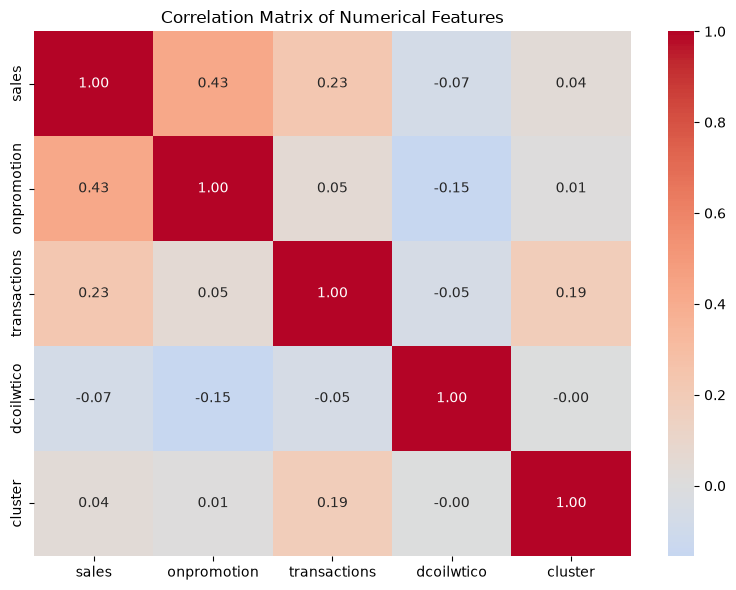

sales           1.000
onpromotion     0.428
transactions    0.233
cluster         0.039
dcoilwtico     -0.075
Name: sales, dtype: float64


In [48]:
numeric_cols = ["sales", "onpromotion", "transactions", "dcoilwtico", "cluster"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

print(corr["sales"].sort_values(ascending=False).round(3))

### Insight

Promotion status shows the strongest linear relationship with sales (r = 0.428), consistent with the family-level analysis where promotional lift ranged from 24% to over 4,000% depending on category. Transaction count follows at r = 0.233, reflecting general store activity but not the monetary value of individual purchases.

Store cluster (r = 0.039) and oil price (r = -0.075) show negligible linear correlation with sales. The cluster result is expected, since cluster is a categorical identifier rather than an ordered quantity, and linear correlation is not a meaningful measure for it.

The weak oil-price correlation is notable given that the dataset documentation highlights Ecuador's oil dependence. This suggests that any macroeconomic effect operates over longer horizons than daily sales variation, and that oil price is unlikely to be a useful direct feature at the daily store-family level.

### 14. Impact of the April 2016 Earthquake

The dataset documentation notes that a magnitude 7.8 earthquake struck Ecuador on 16 April 2016, and that relief efforts significantly affected supermarket sales in the following weeks. We examine whether this event is visible in the data and how it was distributed across stores.

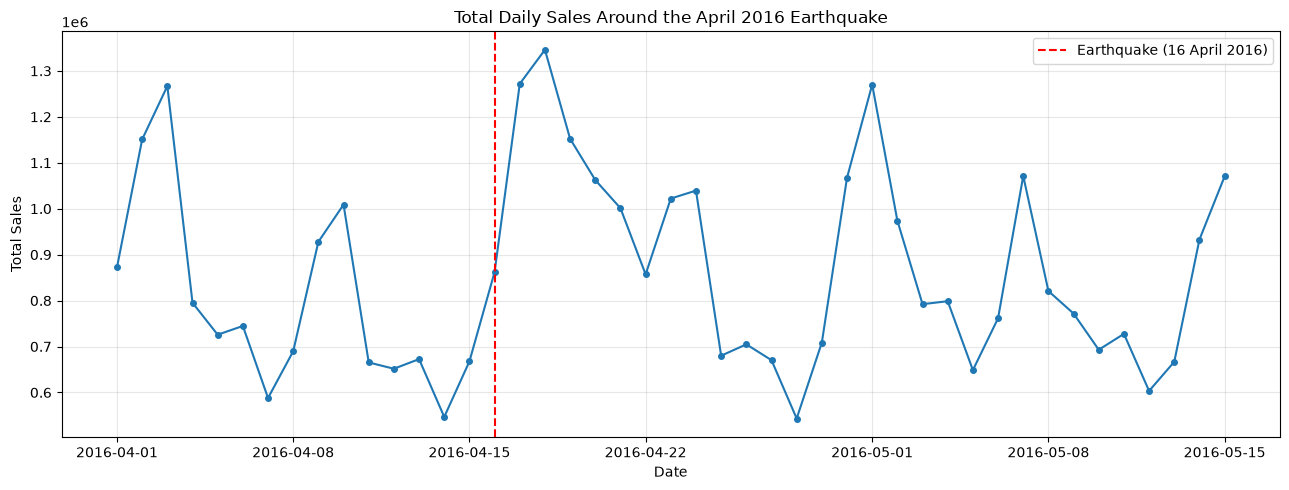

In [49]:
quake_period = train[train["date"].between("2016-04-01", "2016-05-15")]
daily_total = quake_period.groupby("date")["sales"].sum()

plt.figure(figsize=(13, 5))
plt.plot(daily_total.index, daily_total.values, marker="o", markersize=4)
plt.axvline(pd.Timestamp("2016-04-16"), color="red", linestyle="--", label="Earthquake (16 April 2016)")
plt.title("Total Daily Sales Around the April 2016 Earthquake")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Isolating the Earthquake Effect from Weekly Seasonality

The sales increase after the earthquake coincides partly with a normal weekend peak. To separate the two, we compare each day against the average for the same weekday during undisturbed periods before and after the event.

In [50]:
train["weekday_num"] = train["date"].dt.dayofweek

baseline_period = train[
    train["date"].between("2016-03-01", "2016-04-10")
    | train["date"].between("2016-05-16", "2016-06-15")
]

baseline_by_weekday = baseline_period.groupby("weekday_num")["sales"].sum() / \
                       baseline_period.groupby("weekday_num")["date"].nunique()

quake_week = train[train["date"].between("2016-04-16", "2016-04-24")]
quake_daily = quake_week.groupby("date").agg(
    total_sales=("sales", "sum"),
    weekday_num=("weekday_num", "first")
)

quake_daily["expected"] = quake_daily["weekday_num"].map(baseline_by_weekday)
quake_daily["lift_pct"] = (
    (quake_daily["total_sales"] - quake_daily["expected"]) / quake_daily["expected"] * 100
).round(1)

print(quake_daily[["total_sales", "expected", "lift_pct"]].round(0).to_string())

            total_sales   expected  lift_pct
date                                        
2016-04-16     862121.0   928548.0      -7.0
2016-04-17    1271834.0  1013440.0      26.0
2016-04-18    1345921.0   716380.0      88.0
2016-04-19    1152089.0   700149.0      64.0
2016-04-20    1062426.0   723459.0      47.0
2016-04-21    1001080.0   608543.0      64.0
2016-04-22     857059.0   721335.0      19.0
2016-04-23    1022143.0   928548.0      10.0
2016-04-24    1039370.0  1013440.0       3.0


### Insight

The earthquake produced a clear but bounded effect on sales. After adjusting for weekly seasonality by comparing each day against the same weekday in undisturbed periods, the pattern is:

- **16 April (day of the earthquake):** −7% — sales fell below the expected level, consistent with the event occurring in the evening and disrupting normal shopping.
- **17–21 April:** sustained elevation, peaking at +88% on 18 April, reflecting relief-driven purchasing of water and essential goods.
- **22–24 April:** rapid decay to +19%, +10%, and +3%, returning to baseline within roughly one week.

The raw sales chart alone would overstate this effect, since the post-earthquake days coincided with a normal weekend peak. The seasonality-adjusted figures isolate the genuine impact.

For modelling purposes, this period represents a non-recurring shock that no forecasting model can anticipate. We will flag 17–23 April 2016 with a binary indicator so the models can account for it rather than treating it as regular demand variation.

### 15. Regular vs Intermittent Demand Patterns

A central premise of this project is that product families differ fundamentally in how their demand behaves: some sell consistently every day, while others sell sporadically with long gaps between transactions. A single forecasting approach is unlikely to serve both patterns equally well.

We quantify this by measuring the proportion of zero-sales days for each product family.

In [51]:
zero_pct = (
    train.groupby("family")["sales"]
    .apply(lambda s: (s == 0).mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

print(zero_pct.to_string())

family
BOOKS                         96.96
BABY CARE                     94.13
SCHOOL AND OFFICE SUPPLIES    74.08
HOME APPLIANCES               73.52
LADIESWEAR                    59.85
MAGAZINES                     56.54
PET SUPPLIES                  54.62
HARDWARE                      47.86
LAWN AND GARDEN               46.78
PLAYERS AND ELECTRONICS       44.89
CELEBRATION                   43.63
HOME CARE                     40.91
HOME AND KITCHEN II           34.71
HOME AND KITCHEN I            34.65
PRODUCE                       28.36
BEAUTY                        26.28
SEAFOOD                       19.36
LIQUOR,WINE,BEER              17.87
LINGERIE                      16.05
AUTOMOTIVE                    12.78
GROCERY II                    12.11
FROZEN FOODS                   8.09
PREPARED FOODS                 8.08
POULTRY                        8.08
PERSONAL CARE                  8.07
GROCERY I                      8.06
EGGS                           8.06
DELI                 

### Separating Structural from Genuine Zeros

The lowest zero-sales rate is identical (8.06%) across several staple families, which indicates a shared structural floor rather than genuine demand behaviour. We investigate this before drawing conclusions about demand patterns.

In [52]:
zeros_per_date = train.groupby("date")["sales"].apply(lambda s: (s == 0).mean() * 100)

print("Dates with highest zero-sales rate:")
print(zeros_per_date.sort_values(ascending=False).head(10).round(2).to_string())

Dates with highest zero-sales rate:
date
2013-01-01    99.05
2015-01-01    98.71
2017-01-01    98.43
2016-01-01    98.37
2014-01-01    97.19
2013-01-27    54.43
2013-02-17    54.32
2013-02-16    53.87
2013-02-24    53.76
2013-01-20    53.65


In [53]:
train_clean = train[~((train["date"].dt.month == 1) & (train["date"].dt.day == 1))].copy()

first_sale = (
    train_clean[train_clean["sales"] > 0]
    .groupby(["store_nbr", "family"])["date"].min()
    .rename("first_sale_date")
)

train_clean = train_clean.merge(first_sale, on=["store_nbr", "family"], how="inner")
train_clean = train_clean[train_clean["date"] >= train_clean["first_sale_date"]]

zero_pct_clean = (
    train_clean.groupby("family")["sales"]
    .apply(lambda s: (s == 0).mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

print(zero_pct_clean.to_string())

family
BABY CARE                     82.13
HOME APPLIANCES               70.48
BOOKS                         65.03
SCHOOL AND OFFICE SUPPLIES    59.10
HARDWARE                      42.57
MAGAZINES                     40.60
PET SUPPLIES                  38.15
LAWN AND GARDEN               32.67
LADIESWEAR                    31.86
PLAYERS AND ELECTRONICS       25.03
CELEBRATION                   23.34
BEAUTY                        20.20
HOME CARE                     19.70
SEAFOOD                       12.70
PRODUCE                       11.79
HOME AND KITCHEN II           11.44
HOME AND KITCHEN I            11.35
LIQUOR,WINE,BEER              11.10
LINGERIE                       9.12
AUTOMOTIVE                     5.59
GROCERY II                     4.87
FROZEN FOODS                   0.52
PREPARED FOODS                 0.51
POULTRY                        0.50
PERSONAL CARE                  0.49
GROCERY I                      0.48
EGGS                           0.48
DELI                 

In [54]:
def classify_demand(pct):
    if pct >= 50:
        return "Intermittent"
    elif pct >= 20:
        return "Irregular"
    else:
        return "Regular"

demand_pattern = zero_pct_clean.to_frame("zero_pct")
demand_pattern["pattern"] = demand_pattern["zero_pct"].apply(classify_demand)

print(demand_pattern["pattern"].value_counts())
print()
print(demand_pattern.to_string())

pattern
Regular         21
Irregular        8
Intermittent     4
Name: count, dtype: int64

                            zero_pct       pattern
family                                            
BABY CARE                      82.13  Intermittent
HOME APPLIANCES                70.48  Intermittent
BOOKS                          65.03  Intermittent
SCHOOL AND OFFICE SUPPLIES     59.10  Intermittent
HARDWARE                       42.57     Irregular
MAGAZINES                      40.60     Irregular
PET SUPPLIES                   38.15     Irregular
LAWN AND GARDEN                32.67     Irregular
LADIESWEAR                     31.86     Irregular
PLAYERS AND ELECTRONICS        25.03     Irregular
CELEBRATION                    23.34     Irregular
BEAUTY                         20.20     Irregular
HOME CARE                      19.70       Regular
SEAFOOD                        12.70       Regular
PRODUCE                        11.79       Regular
HOME AND KITCHEN II            11.44     

In [55]:
# Classify demand pattern for each Store × Family series

series_demand_pattern = (
    train_clean
    .groupby(["store_nbr", "family"])["sales"]
    .agg(
        zero_pct=lambda s: (s == 0).mean() * 100
    )
    .reset_index()
)

series_demand_pattern["pattern"] = (
    series_demand_pattern["zero_pct"]
    .apply(classify_demand)
)

series_demand_pattern.head(10)

,store_nbr,family,zero_pct,pattern
0,1,AUTOMOTIVE,12.864800,Regular
1,1,BEAUTY,14.830256,Regular
2,1,BEVERAGES,0.059559,Regular
3,1,BOOKS,58.360656,Intermittent
4,1,BREAD/BAKERY,0.059559,Regular
5,1,CELEBRATION,24.088146,Irregular
6,1,CLEANING,0.059559,Regular
7,1,DAIRY,0.059559,Regular
8,1,DELI,0.059559,Regular
9,1,EGGS,0.059559,Regular


In [56]:
print("Number of Store × Family series:", len(series_demand_pattern))

print("\nPattern counts:")
print(series_demand_pattern["pattern"].value_counts())

print("\nPattern percentages:")
print(
    series_demand_pattern["pattern"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Number of Store × Family series: 1729

Pattern counts:
pattern
Regular         1128
Irregular        378
Intermittent     223
Name: count, dtype: int64

Pattern percentages:
pattern
Regular         65.24
Irregular       21.86
Intermittent    12.90
Name: proportion, dtype: float64


In [57]:
# Find Store × Family series with no positive sales

all_series = df[["store_nbr", "family"]].drop_duplicates()

series_sales = (
    df.groupby(["store_nbr", "family"])["sales"]
      .agg(
          total_sales="sum",
          positive_sales_days=lambda s: (s > 0).sum(),
          zero_sales_days=lambda s: (s == 0).sum()
      )
      .reset_index()
)

no_demand_series = series_sales[series_sales["positive_sales_days"] == 0]

print("Store × Family series with no positive sales:",
      len(no_demand_series))

print("\nThese series:")
print(no_demand_series.to_string(index=False))

Store × Family series with no positive sales: 53

These series:
 store_nbr          family  total_sales  positive_sales_days  zero_sales_days
         1       BABY CARE          0.0                    0             1684
         9           BOOKS          0.0                    0             1684
        10           BOOKS          0.0                    0             1684
        11           BOOKS          0.0                    0             1684
        12           BOOKS          0.0                    0             1684
        13       BABY CARE          0.0                    0             1684
        13           BOOKS          0.0                    0             1684
        14           BOOKS          0.0                    0             1684
        14 LAWN AND GARDEN          0.0                    0             1684
        15           BOOKS          0.0                    0             1684
        16           BOOKS          0.0                    0             1684


In [58]:
# Add "No observed demand" for Store × Family series
# with no positive sales during the training period

series_demand_pattern_final = series_demand_pattern.copy()

no_demand_keys = no_demand_series[["store_nbr", "family"]].copy()
no_demand_keys["zero_pct"] = 100.0
no_demand_keys["pattern"] = "No observed demand"

series_demand_pattern_final = pd.concat(
    [series_demand_pattern_final, no_demand_keys],
    ignore_index=True
)

print("Total Store × Family series:",
      len(series_demand_pattern_final))

print("\nPattern counts:")
print(
    series_demand_pattern_final["pattern"]
    .value_counts()
)

print("\nPattern percentages:")
print(
    series_demand_pattern_final["pattern"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Total Store × Family series: 1782

Pattern counts:
pattern
Regular               1128
Irregular              378
Intermittent           223
No observed demand      53
Name: count, dtype: int64

Pattern percentages:
pattern
Regular               63.30
Irregular             21.21
Intermittent          12.51
No observed demand     2.97
Name: proportion, dtype: float64


### Visualising the Two Extremes

To illustrate the difference in demand behaviour, we compare a representative regular family with a representative intermittent family over the same period.

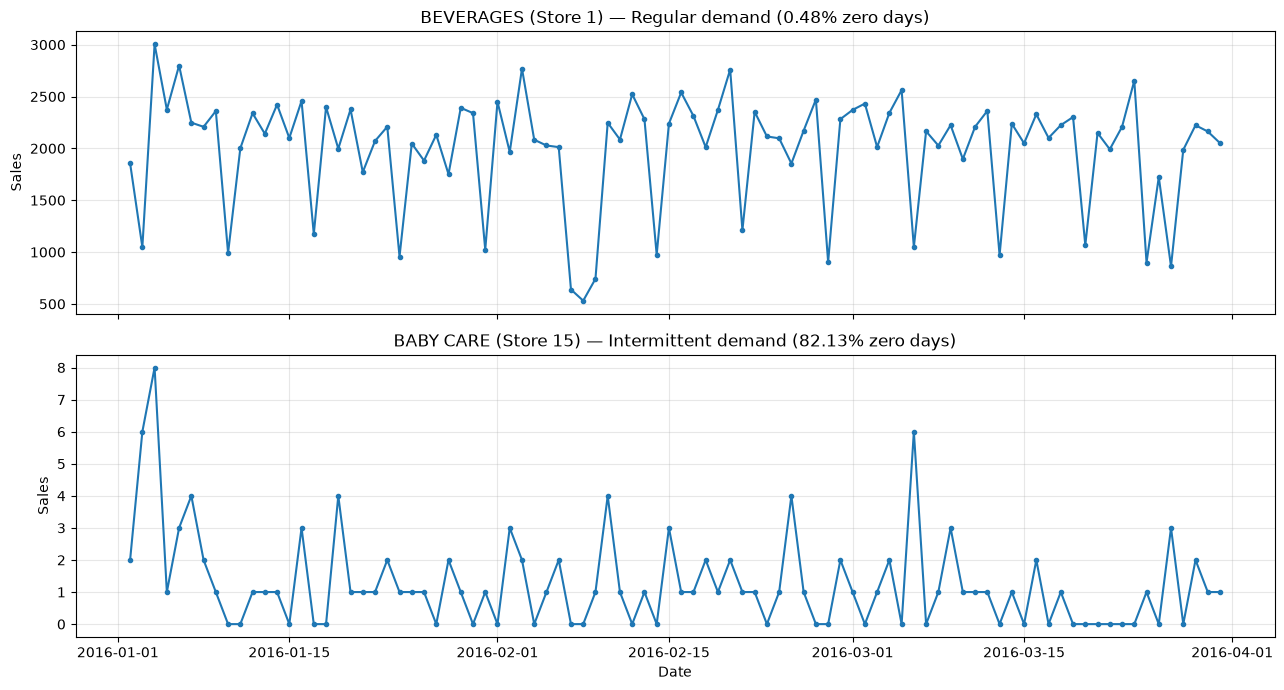

In [59]:
period = ("2016-01-01", "2016-03-31")

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

configs = [
    (1, "BEVERAGES", "Regular demand (0.48% zero days)"),
    (15, "BABY CARE", "Intermittent demand (82.13% zero days)")
]

for ax, (store, fam, label) in zip(axes, configs):
    series = train_clean[
        (train_clean["store_nbr"] == store)
        & (train_clean["family"] == fam)
        & (train_clean["date"].between(*period))
    ].set_index("date")["sales"]

    ax.plot(series.index, series.values, marker="o", markersize=3)
    ax.set_title(f"{fam} (Store {store}) — {label}")
    ax.set_ylabel("Sales")
    ax.grid(alpha=0.3)

axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

### Insight

Product families differ fundamentally in demand behaviour. After removing structural zeros (New Year closures and pre-launch periods for each store-family combination), zero-sales rates range from 0.48% for staples such as Beverages, Dairy and Bread to 82.13% for Baby Care.

The cleaning step is essential: raw zero-sales rates showed an identical 8.06% floor across all staple families, which reflected shared closure days rather than genuine demand behaviour. After correction, Books dropped from 96.96% to 65.03% and Baby Care from 94.13% to 82.13%, and the ranking of the most intermittent families changed.

We classify each Store × Family time series into three demand-pattern groups based on the cleaned zero-sales rate:

- **Intermittent (≥50% zero days):** 223 Store × Family series
- **Irregular (20–50%):** 378 Store × Family series
- **Regular (<20%):** 1,128 Store × Family series

In addition, 53 Store × Family series have no observed positive sales during the training period and are labelled **No observed demand** rather than Intermittent.

The contrast is visible in the two series plotted above: Beverages shows a continuous line with strong weekly seasonality, while Baby Care alternates between zero and sporadic spikes with no stable pattern.

This confirms the core premise of the project. Standard time-series models rely on continuity and recent history, both of which are absent in intermittent series. Applying a single modelling strategy across all Store × Family series could systematically underperform on intermittent demand, which justifies evaluating model performance separately by demand pattern.

### 16. Candidate Features for Forecasting

Based on the patterns identified above, we summarise the features most likely to carry predictive signal, along with the reasoning behind each.

**Strong candidates**

- `onpromotion` — the strongest single predictor (r = 0.428), with effects varying substantially by product family. Should be modelled as an interaction with family rather than a global effect.
- `family` — demand levels and promotional response differ by two orders of magnitude across categories.
- `day_of_week` — weekend sales are roughly 1.6 times higher than the weakest weekday.
- `is_holiday` — national holidays show a 19% uplift, confirmed against random-sample variation.
- `store_type` — a 3.6-fold gap between the highest and lowest performing types.
- `store_nbr` — substantial store-level variation beyond what type alone explains.
- `demand_pattern` — each Store × Family series is classified as Regular (<20%), Irregular (20–50%), or Intermittent (≥50%) based on the cleaned zero-sales rate. Series with no observed positive sales are labelled separately as No observed demand. This distinction supports evaluating model performance separately by demand pattern.

**Moderate candidates**

- `transactions` — captures general store activity (r = 0.233), though it reflects footfall rather than basket value.
- `month` — moderate seasonal variation, with December highest and February lowest.

**Weak or excluded**

- `dcoilwtico` — negligible correlation at the daily level (r = -0.075). Any macroeconomic effect appears to operate over longer horizons than daily demand variation.
- `year` — shows a strong upward trend, but this is partly an artifact of incomplete category tracking in early periods and should not be used as a direct trend feature without correction.
- `cluster` — a categorical identifier; linear correlation is not meaningful, though it may still hold value if encoded appropriately.

**Features to engineer**

Lag features (`lag_1`, `lag_7`, `lag_14`) and rolling statistics (`rolling_mean_7`, `rolling_mean_14`) are expected to be essential for time-series forecasting, capturing recent demand levels and short-term momentum that none of the raw columns provide.

An `earthquake_period` binary flag (17–23 April 2016) should also be included, to prevent the models from treating a one-off shock as recurring demand behaviour.

### 17. Forecasting Granularity

Based on the structure of the data and the patterns identified above, we define the forecasting granularity as **date × store × product family** — the same level at which the raw data is recorded.

This level is chosen because store-level and family-level effects are both substantial and independent: average sales vary 23-fold across stores and show a 3.6-fold gap across store types, while promotional response ranges from 24% to over 4,000% depending on product family. Aggregating to either store level or family level alone would discard signal that the other dimension carries.

Critically, the intermittent demand pattern identified above is only visible at this level of detail. Aggregating across stores would mask zero-sales days entirely, since the sum across 54 stores is rarely zero even for sparse families — eliminating the very signal the project aims to model.

This yields 1,782 individual time series (54 stores × 33 families), each forecast over a 15-day horizon.

# Modeling Preparation

We prepare the cleaned Store × Family time series for forecasting.  
Each series is associated with its demand pattern, and the dataset is checked before feature engineering and model training.

In [60]:
# Create the modeling dataset from the merged data
# while removing structural zeros

modeling_df = df[
    ~(
        (df["date"].dt.month == 1) &
        (df["date"].dt.day == 1)
    )
].copy()

# Find the first observed sale for each Store × Family
first_sale = (
    modeling_df[modeling_df["sales"] > 0]
    .groupby(["store_nbr", "family"])["date"]
    .min()
    .rename("first_sale_date")
)

# Keep observations from the first actual sale onward
modeling_df = modeling_df.merge(
    first_sale,
    on=["store_nbr", "family"],
    how="inner"
)

modeling_df = modeling_df[
    modeling_df["date"] >= modeling_df["first_sale_date"]
].copy()

print("Shape:", modeling_df.shape)
print("\nColumns:")
print(modeling_df.columns.tolist())

Shape: (2438831, 16)

Columns:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'weekday', 'year', 'month', 'city', 'state', 'type', 'cluster', 'transactions', 'dcoilwtico', 'first_sale_date']


In [61]:
# Check Store × Family series after cleaning

series_check = (
    modeling_df.groupby(["store_nbr", "family"])
    .agg(
        rows=("date", "size"),
        unique_dates=("date", "nunique"),
        min_date=("date", "min"),
        max_date=("date", "max")
    )
    .reset_index()
)

print("Number of Store × Family series:", len(series_check))

print("\nUnique date counts:")
print(series_check["unique_dates"].value_counts().sort_index())

print("\nDuplicate Store × Family × Date rows:",
      modeling_df.duplicated(
          subset=["store_nbr", "family", "date"]
      ).sum())

Number of Store × Family series: 1729

Unique date counts:
unique_dates
37        1
118      32
247       1
252       1
280       1
       ... 
1675      3
1676      8
1677     11
1678     27
1679    864
Name: count, Length: 129, dtype: int64

Duplicate Store × Family × Date rows: 0


In [62]:
# Merge Store × Family demand patterns

modeling_df = modeling_df.merge(
    series_demand_pattern_final[
        ["store_nbr", "family", "pattern"]
    ],
    on=["store_nbr", "family"],
    how="left"
)

print("Shape:", modeling_df.shape)

print("\nMissing patterns:")
print(modeling_df["pattern"].isna().sum())

print("\nPattern distribution:")
print(modeling_df["pattern"].value_counts())

Shape: (2438831, 17)

Missing patterns:
0

Pattern distribution:
pattern
Regular         1681404
Irregular        506246
Intermittent     251181
Name: count, dtype: int64


In [63]:
# Verify one unique pattern per Store × Family

pattern_check = (
    modeling_df
    .groupby(["store_nbr", "family"])["pattern"]
    .nunique()
)

print("Store × Family series:", len(pattern_check))
print("Series with multiple patterns:", (pattern_check > 1).sum())
print("Series with missing pattern:", (pattern_check == 0).sum())

Store × Family series: 1729
Series with multiple patterns: 0
Series with missing pattern: 0


 ## Final Demand Pattern Classification for Modeling

There are 1,782 possible Store × Family time series in the dataset (54 stores × 33 product families).

After removing structural zeros and pre-launch periods, 1,729 Store × Family series have at least one observed positive sale and are included in the modeling dataset:

- **1,128 Regular** series
- **378 Irregular** series
- **223 Intermittent** series

The remaining **53 Store × Family series** have no observed positive sales during the training period. They are labelled **No observed demand** and excluded from the modeling dataset because there is no historical positive demand from which to learn a demand pattern.

### Modeling Preparation Flow

Raw / merged data  
↓  
Structural-zero cleaning  
↓  
First sale per Store × Family  
↓  
Demand pattern classification  
↓  
Regular / Irregular / Intermittent  
↓  
Modeling dataset (`modeling_df`)  
↓  
**Ready for Feature Engineering**

## Feature Engineering

## 1. Sort the Data

Before creating time-series features, we sort the data by Store, Product Family, and Date.

This ensures that all lag and rolling features are calculated in the correct chronological order within each Store × Family series.

In [64]:
modeling_df = modeling_df.sort_values(
    ["store_nbr", "family", "date"]
).reset_index(drop=True)

modeling_df.head()

,id,date,store_nbr,family,sales,onpromotion,weekday,year,month,city,state,type,cluster,transactions,dcoilwtico,first_sale_date,pattern
0,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,Wednesday,2013,1,Quito,Pichincha,D,13,2111.0,93.14,2013-01-02,Regular
1,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,Thursday,2013,1,Quito,Pichincha,D,13,1833.0,92.97,2013-01-02,Regular
2,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,Friday,2013,1,Quito,Pichincha,D,13,1863.0,93.12,2013-01-02,Regular
3,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,Saturday,2013,1,Quito,Pichincha,D,13,1509.0,93.12,2013-01-02,Regular
4,8910,2013-01-06,1,AUTOMOTIVE,2.0,0,Sunday,2013,1,Quito,Pichincha,D,13,520.0,93.12,2013-01-02,Regular


## 2. Lag 1 — Previous Day Sales

`lag_1` represents the sales of the previous day for the same Store × Family series.

It helps the model capture very recent demand behavior and short-term changes in sales.

The value is shifted by one day so that the feature only uses information that was available before the prediction date.

In [65]:
modeling_df["lag_1"] = (
    modeling_df
    .groupby(["store_nbr", "family"])["sales"]
    .shift(1)
)

## 3. Lag 7 — Sales from the Previous Week

`lag_7` represents the sales from exactly 7 days earlier for the same Store × Family series.

This is useful because retail sales often have weekly patterns. For example, demand on a Sunday may be more similar to the previous Sunday's demand than to the previous Saturday's demand.

Using a 7-day lag allows the model to capture this weekly seasonality.

In [66]:
modeling_df["lag_7"] = (
    modeling_df
    .groupby(["store_nbr", "family"])["sales"]
    .shift(7)
)

## 4. Lag 14 — Sales from Two Weeks Earlier

`lag_14` represents the sales from 14 days earlier for the same Store × Family series.

It provides the model with additional information about repeated weekly patterns and helps compare current demand with the same day of the week from two weeks ago.

In [67]:
modeling_df["lag_14"] = (
    modeling_df
    .groupby(["store_nbr", "family"])["sales"]
    .shift(14)
)

## 5. Rolling Mean 7 — Recent Weekly Average

`rolling_mean_7` represents the average sales over the previous 7 days for the same Store × Family series.

We first shift the sales by one day before calculating the rolling mean. This prevents data leakage by ensuring that the current day's sales are not included in the feature.

This feature helps the model understand the recent average level of demand rather than relying only on a single previous day.

In [68]:
modeling_df["rolling_mean_7"] = (
    modeling_df
    .groupby(["store_nbr", "family"])["sales"]
    .transform(lambda s: s.shift(1).rolling(7).mean())
)

## 6. Rolling Mean 14 — Recent Two-Week Average

`rolling_mean_14` represents the average sales over the previous 14 days.

It provides a smoother view of recent demand and reduces the effect of unusually high or low sales on a single day.

As with the 7-day rolling mean, the sales are shifted by one day first to prevent data leakage.

In [69]:
modeling_df["rolling_mean_14"] = (
    modeling_df
    .groupby(["store_nbr", "family"])["sales"]
    .transform(lambda s: s.shift(1).rolling(14).mean())
)

## 7. Rolling Mean 28 — Recent Four-Week Average

`rolling_mean_28` represents the average sales over the previous 28 days.

A 28-day window captures a longer-term view of demand while still reflecting recent behavior.

This can help the model distinguish between short-term fluctuations and more stable demand levels.

In [70]:
modeling_df["rolling_mean_28"] = (
    modeling_df
    .groupby(["store_nbr", "family"])["sales"]
    .transform(lambda s: s.shift(1).rolling(28).mean())
)

## 8. Month — Monthly Seasonality

The `month` feature represents the month of the year.

Retail demand can vary across different months because of seasonal purchasing patterns, holidays, and other recurring yearly effects.

The month feature allows the model to learn these seasonal differences.

## 9. Weekday — Day-of-Week Pattern

The `weekday` feature represents the day of the week.

Retail sales can differ significantly between weekdays and weekends. Including the weekday allows the model to learn recurring weekly demand patterns.

This is particularly relevant because our EDA showed noticeable differences in average sales across days of the week.

## 10. Promotion — Promotional Activity

The `onpromotion` feature represents the number of products in the Store × Family combination that were on promotion on a given day.

Promotions can have a strong effect on sales, so this feature helps the model understand changes in demand associated with promotional activity.

## 11. Transactions — Store Activity

The `transactions` feature represents the number of transactions recorded for a store on a given day.

It provides information about overall store activity and can help the model distinguish between changes in product demand and changes in the number of customers making purchases.

## 12. Oil Price — External Economic Signal

The `dcoilwtico` feature represents the daily oil price.

Because the dataset is from Ecuador, changes in oil prices may provide an external economic signal that can be useful for explaining changes in retail demand.

The feature is included as an external variable that the models can evaluate for predictive usefulness.

In [71]:
feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

modeling_df[feature_cols].head(10)

,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_mean_28
0,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,NaN,NaN,NaN,NaN,NaN
2,3.0,NaN,NaN,NaN,NaN,NaN
3,3.0,NaN,NaN,NaN,NaN,NaN
4,5.0,NaN,NaN,NaN,NaN,NaN
5,2.0,NaN,NaN,NaN,NaN,NaN
6,0.0,NaN,NaN,NaN,NaN,NaN
7,2.0,2.0,NaN,2.428571,NaN,NaN
8,2.0,3.0,NaN,2.428571,NaN,NaN
9,2.0,3.0,NaN,2.285714,NaN,NaN


## Handling Missing Values from Lag and Rolling Features

The missing values created by lag and rolling features occur only at the beginning of each Store × Family series.

These rows do not contain enough historical information to calculate the required features. Therefore, they cannot be used for model training.

We remove rows with missing values in the time-series features before preparing the data for modeling.

In [72]:
modeling_df = modeling_df.dropna(
    subset=feature_cols
).copy()

modeling_df.shape

(2390419, 23)

## Final Check for Time-Series Features

After removing the initial rows without sufficient historical information, we verify that all lag and rolling features are complete.

This ensures that the dataset is ready for the next modeling preparation steps.

In [73]:
modeling_df[feature_cols].isna().sum()

lag_1              0
lag_7              0
lag_14             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_28    0
dtype: int64

## Preparing Features and Target

The target variable for our forecasting models is `sales`, which represents the number of units sold.

The remaining selected features provide information about recent demand, weekly patterns, promotions, store activity, and external factors.

We separate the target variable from the input features before splitting the data into training and validation sets.

In [74]:
feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "onpromotion",
    "weekday",
    "month",
    "year",
    "transactions",
    "dcoilwtico"
]

target_col = "sales"

X = modeling_df[feature_cols]
y = modeling_df[target_col]

X.shape, y.shape

((2390419, 12), (2390419,))

## Chronological Train-Validation Split

Because this is a time-series forecasting problem, the data must be split chronologically rather than randomly.

The model is trained on earlier observations and validated on later observations. This prevents information from the future from being used during training.

We use the last 15 days of the available data as the validation period, matching the project's 15-day forecasting horizon.

In [75]:
validation_days = 15

max_date = modeling_df["date"].max()
validation_start = max_date - pd.Timedelta(days=validation_days - 1)

max_date, validation_start

(Timestamp('2017-08-15 00:00:00'), Timestamp('2017-08-01 00:00:00'))

In [76]:
train_mask = modeling_df["date"] < validation_start
validation_mask = modeling_df["date"] >= validation_start

X_train = X.loc[train_mask]
X_valid = X.loc[validation_mask]

y_train = y.loc[train_mask]
y_valid = y.loc[validation_mask]

In [77]:
print("Training period:", modeling_df.loc[train_mask, "date"].min(),
      "to", modeling_df.loc[train_mask, "date"].max())

print("Validation period:", modeling_df.loc[validation_mask, "date"].min(),
      "to", modeling_df.loc[validation_mask, "date"].max())

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

Training period: 2013-01-30 00:00:00 to 2017-07-31 00:00:00
Validation period: 2017-08-01 00:00:00 to 2017-08-15 00:00:00
X_train: (2364490, 12)
X_valid: (25929, 12)
y_train: (2364490,)
y_valid: (25929,)


In [78]:
print("Last training date:", modeling_df.loc[train_mask, "date"].max())
print("First validation date:", modeling_df.loc[validation_mask, "date"].min())

print(
    "Date overlap:",
    set(modeling_df.loc[train_mask, "date"]).intersection(
        set(modeling_df.loc[validation_mask, "date"])
    )
)

Last training date: 2017-07-31 00:00:00
First validation date: 2017-08-01 00:00:00
Date overlap: set()


## Train-Validation Split Check

The chronological split creates a training period from January 30, 2013 to July 31, 2017 and a 15-day validation period from August 1 to August 15, 2017.

The validation period contains only dates after the training period, ensuring that future observations are not used to train the model.

This setup allows us to evaluate how well the models forecast unseen future demand.

In [79]:
train_df = modeling_df[train_mask].copy()
valid_df = modeling_df[validation_mask].copy()

In [80]:
train_df.to_parquet(
    "../data/processed/train_df.parquet",
    index=False
)

valid_df.to_parquet(
    "../data/processed/valid_df.parquet",
    index=False
)

In [81]:
print(train_df.shape)
print(valid_df.shape)

(2364490, 23)
(25929, 23)


## Seasonal Naive Baseline

The Seasonal Naive model provides a simple baseline for comparison with the machine learning models.

Because the data is daily and shows weekly demand patterns, we use a seasonal period of 7 days.

For each Store × Family series, the forecast for a given day is based on the sales observed 7 days earlier.

This baseline does not learn complex relationships between features. Instead, it assumes that the weekly demand pattern repeats over time.

The performance of XGBoost and LightGBM will be compared against this baseline.